# Lab 01: Cotizaciones optimas de un formador de mercado

**Modelo de Copeland y Galai (1983)**

Este notebook solo importa funciones de `src/` y genera las figuras y tablas del analisis. Toda la logica del modelo vive en `src/model.py`, la simulacion en `src/simulation.py` y las graficas en `src/plots.py`. Para reproducir todo desde la terminal: `python main.py`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# El notebook vive en notebooks/, asi que la raiz del repo es un nivel arriba
sys.path.insert(0, str(Path.cwd().resolve().parent))

from src import plots
from src.model import (ModelParams, expected_utility, expected_informed_loss,
                       expected_liquidity_gain, optimize_quotes,
                       sensitivity_to_pi_informed)
from src.simulation import (DEFAULT_SEED, monte_carlo_stats, run_monte_carlo,
                            simulate_trades, summarize_run)

%matplotlib inline
np.random.seed(DEFAULT_SEED)
params = ModelParams()
params

ModelParams(s0=19.9, k=60, lam=3.0, pi_informed=0.4, alpha=0.5, beta=0.08)

## 1. Cotizaciones optimas

Maximizamos $\Pi(A,B)$ minimizando su negativo con `scipy.optimize.minimize` (L-BFGS-B) bajo $B \in (0, S_0]$ y $A \in [S_0, \infty)$.

In [2]:
sol = optimize_quotes(params)

pd.DataFrame({
    "Bid optimo": [sol.bid],
    "Ask optimo": [sol.ask],
    "Spread": [sol.spread],
    "Utilidad esperada por trade": [sol.expected_utility],
}).round(2)

,Bid optimo,Ask optimo,Spread,Utilidad esperada por trade
0,16.45,23.43,6.98,0.84


## 2. Figura 1: probabilidad de ejecucion contra spread

La demanda no informada $\pi_{LB}(s) = \pi_{LS}(s) = \max(0,\ 0.50 - 0.08 s)$ se anula en $s = 6.25$.

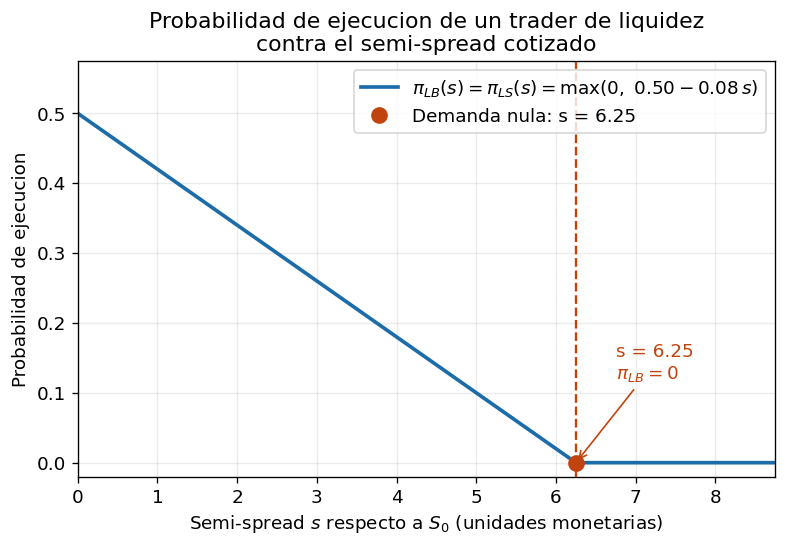

In [3]:
fig = plots.plot_execution_probability(params)
plt.show()

## 3. Simulacion de 10,000 trades por regimen

Tres regimenes: optimo (resultado de la seccion 1), estrecho (19.75 / 20.05) y amplio (18.40 / 21.40). La ejecucion es forzada en cada llegada, como pide el enunciado.

In [4]:
N_TRADES = 10_000
regimes = {
    "Optimo":   (round(sol.bid, 2), round(sol.ask, 2)),
    "Estrecho": (19.75, 20.05),
    "Amplio":   (18.40, 21.40),
}

runs, rows = {}, []
for name, (bid, ask) in regimes.items():
    rng = np.random.default_rng(DEFAULT_SEED)
    runs[name] = simulate_trades(bid, ask, n_trades=N_TRADES, params=params, rng=rng)
    s = summarize_run(runs[name])
    rows.append({
        "Regimen": name, "Bid": bid, "Ask": ask, "Spread": ask - bid,
        "P&L total": s["total_pnl"],
        "P&L por trade": s["mean_pnl_per_arrival"],
        "P&L vs liquidez": s["pnl_from_liquidity"],
        "P&L vs informados": s["pnl_from_informed"],
        "Trades informados": s["n_informed_trades"],
        "Inventario final": s["final_inventory"],
        "Max |inventario|": s["max_abs_inventory"],
    })

resumen = pd.DataFrame(rows).set_index("Regimen")
resumen.round(2)

,Bid,Ask,Spread,P&L total,P&L por trade,P&L vs liquidez,P&L vs informados,Trades informados,Inventario final,Max |inventario|
Regimen,,,,,,,,,,
Optimo,16.45,23.43,6.98,19925.23,1.99,20821.74,-896.51,713,-105,148
Estrecho,19.75,20.05,0.30,-6887.78,-0.69,894.90,-7782.68,3843,-51,117
Amplio,18.40,21.40,3.00,5246.39,0.52,8949.00,-3702.61,2249,1,88


### Figura 2: P&L acumulado

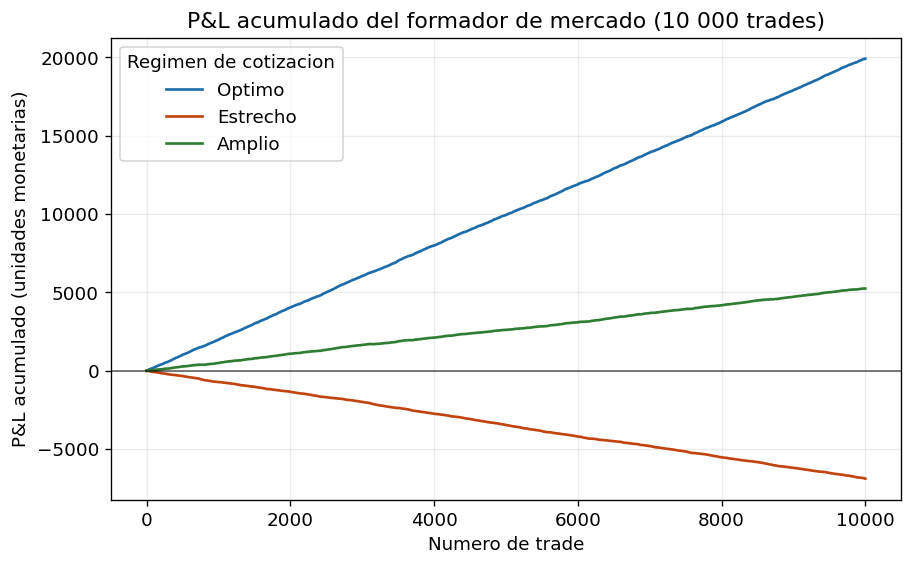

In [5]:
fig = plots.plot_cumulative_pnl(runs)
plt.show()

### Figura 3: inventario acumulado

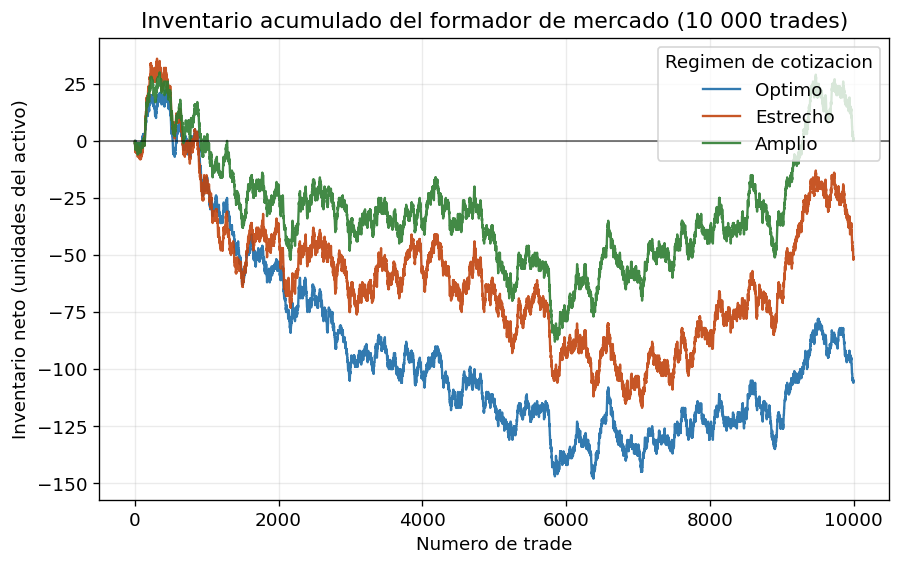

In [6]:
fig = plots.plot_inventory(runs)
plt.show()

## 4. Costo de seleccion adversa contra spread

Para responder como cambia el costo de seleccion adversa al ampliar el spread, evaluamos la perdida esperada frente a informados $\pi_I \cdot L(A,B)$ para spreads simetricos alrededor de $S_0$.

In [7]:
half_spreads = np.array([0.15, 0.5, 1.0, 1.5, 2.0, 3.0, 3.49, 4.0, 5.0])
tabla = pd.DataFrame({
    "Semi-spread": half_spreads,
    "Spread total": 2 * half_spreads,
    "Ganancia vs liquidez": [params.pi_liquidity * expected_liquidity_gain(params.s0 + h, params.s0 - h, params) for h in half_spreads],
    "Perdida vs informados": [params.pi_informed * expected_informed_loss(params.s0 + h, params.s0 - h, params) for h in half_spreads],
})
tabla["Utilidad esperada"] = tabla["Ganancia vs liquidez"] - tabla["Perdida vs informados"]
tabla.round(4)

,Semi-spread,Spread total,Ganancia vs liquidez,Perdida vs informados,Utilidad esperada
0,0.15,0.30,0.0878,0.7635,-0.6757
1,0.50,1.00,0.2760,0.6376,-0.3616
2,1.00,2.00,0.5040,0.4834,0.0206
3,1.50,3.00,0.6840,0.3579,0.3261
4,2.00,4.00,0.8160,0.2585,0.5575
5,3.00,6.00,0.9360,0.1251,0.8109
6,3.49,6.98,0.9247,0.0846,0.8401
7,4.00,8.00,0.8640,0.0550,0.8090
8,5.00,10.00,0.6000,0.0222,0.5778


## 5. Monte Carlo: 1,000 corridas de 1,000 trades

In [8]:
MC_RUNS, MC_TRADES = 1_000, 1_000
mc_results, mc_rows = {}, []
for name, (bid, ask) in regimes.items():
    mc = run_monte_carlo(bid, ask, n_runs=MC_RUNS, n_trades=MC_TRADES,
                         params=params, seed=DEFAULT_SEED)
    mc_results[name] = mc["final_pnl"].to_numpy()
    st = monte_carlo_stats(mc)
    mc_rows.append({
        "Regimen": name,
        "P&L promedio": st["mean_pnl"],
        "Desv. estandar": st["std_pnl"],
        "Prob. de perdida": st["prob_loss"],
        "|Inventario| medio": st["mean_abs_inventory"],
    })

pd.DataFrame(mc_rows).set_index("Regimen").round(3)

,P&L promedio,Desv. estandar,Prob. de perdida,|Inventario| medio
Regimen,,,,
Optimo,2011.700,58.391,0.0,21.196
Estrecho,-673.389,44.837,1.0,25.186
Amplio,542.740,44.826,0.0,22.463


### Figura 4: histograma del P&L final

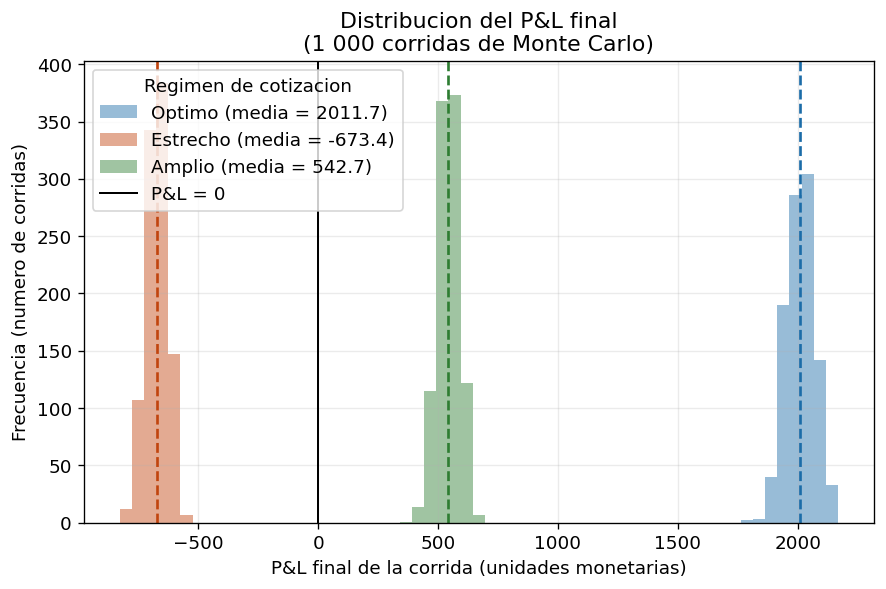

In [9]:
fig = plots.plot_mc_histogram(mc_results)
plt.show()

## 6. Sensibilidad a $\pi_I$

Reoptimizamos para $\pi_I \in \{0.1, 0.4, 0.7\}$ y comparamos contra la referencia sin seleccion adversa ($\pi_I = 0$), donde el monopolista cotiza $s^* = \alpha/(2\beta) = 3.125$ por lado, es decir un spread total de $\alpha/\beta = 6.25$.

In [10]:
sens = sensitivity_to_pi_informed([0.0, 0.1, 0.4, 0.7], params)
pd.DataFrame(sens).round(2)

,pi_informed,bid,ask,spread,expected_utility
0,0.0,16.78,23.03,6.25,1.56
1,0.1,16.71,23.11,6.40,1.38
2,0.4,16.45,23.43,6.98,0.84
3,0.7,16.01,24.00,7.99,0.34


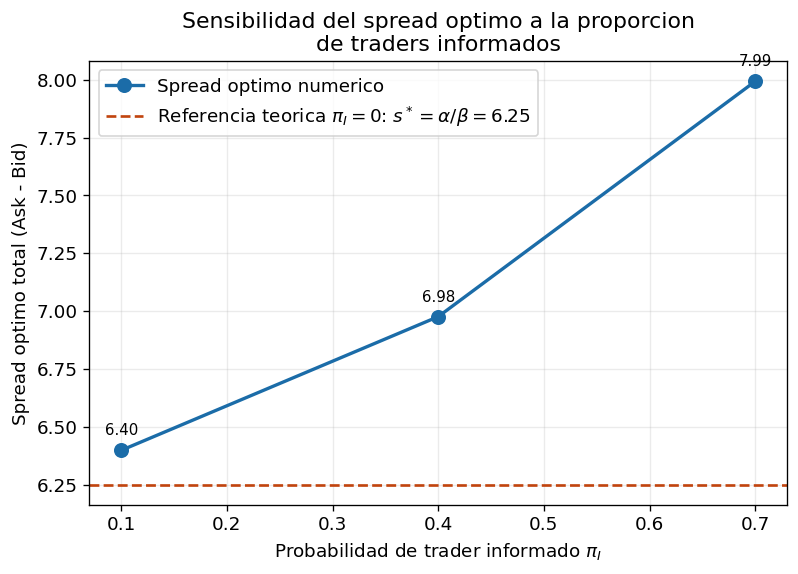

In [11]:
fig = plots.plot_spread_sensitivity([r for r in sens if r["pi_informed"] > 0], params)
plt.show()

## Advertencia de interpretacion

La simulacion fuerza un trade en cada llegada, asi que las cifras son rentabilidad **por trade** y no por unidad de tiempo. Un spread muy amplio, que en un mercado real casi nunca se ejecutaria, sale favorecido bajo esta metrica. Las respuestas a las preguntas de analisis estan en el `README.md`.